<a href="https://colab.research.google.com/github/antonellagambarte/vision-por-computadoras-II/blob/main/entrega%20final/modelos_basicos_con_data_augmentation_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Optimizado para Clasificación de Enfermedades en Plantas

Este notebook mejora el pipeline anterior con las siguientes optimizaciones:

1. **Eliminación de imágenes duplicadas**: Detectamos y removemos imágenes duplicadas usando hashing perceptual para evitar sesgos en el entrenamiento
2. **Data Augmentation en clases subrepresentadas**: Aplicamos aumento de datos específicamente en las clases con menor representación para balancear el dataset
3. **Técnicas de balanceo del dataset** (sugeridas por el profesor):
   - **WeightedRandomSampler**: Muestrea aleatoriamente el dataset dando mayor probabilidad a las clases menos representadas, uniformando la distribución durante el entrenamiento
   - **Pesos por clase en CrossEntropyLoss**: Penaliza los errores en las clases menos pobladas, haciendo que el modelo les preste más atención
4. **Búsqueda de hiperparámetros con Optuna**: Optimizamos automáticamente learning rate, batch size, y arquitectura del clasificador

**Modelos a comparar:**
- MobileNetV2
- MobileNetV3

**Objetivo**: Maximizar recall y accuracy mientras mantenemos el modelo lo suficientemente ligero para deployment móvil.


In [1]:
test_execution = True


## Imports y Configuración Inicial


In [2]:
#!pip install optuna

In [3]:
import gdown
import zipfile
import os
import time
import copy
import hashlib
from pathlib import Path
from collections import Counter, defaultdict
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import cv2

from sklearn.metrics import (confusion_matrix, accuracy_score, recall_score,
                            f1_score, roc_curve, auc, precision_recall_curve,
                            average_precision_score)
from sklearn.preprocessing import LabelBinarizer

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torch.ao.quantization import get_default_qconfig_mapping, get_default_qat_qconfig_mapping
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx, prepare_qat_fx

import optuna
from optuna.trial import TrialState
import warnings

import torch.multiprocessing as mp
mp.set_start_method('fork', force=True)

#torch.backends.cudnn.benchmark = True
torch.utils.data.dataloader._MultiProcessingDataLoaderIter.__del__ = lambda self: None

# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Para asegurar reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Silenciar warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


/Users/cespinola/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Usando dispositivo: cpu


## Carga del Dataset


In [4]:
url = "https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri"
output = "archivo.zip"
destino = "datos_zip"

def zip_is_valid(path):
    if not os.path.isfile(path) or os.path.getsize(path) == 0:
        return False
    try:
        with zipfile.ZipFile(path, 'r') as z:
            return z.testzip() is None
    except Exception as e:
        print("Error:", e)
        return False

# Descargar solo si no existe o si el zip es inválido
if not zip_is_valid(output):
    print("Descargando dataset...")
    gdown.download(url, output, quiet=False, fuzzy=True)
else:
    print(f"'{output}' ya existe.")

os.makedirs(destino, exist_ok=True)
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

print("Archivo extraído correctamente en:", destino)


Descargando dataset...


Downloading...
From (original): https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri
From (redirected): https://drive.google.com/uc?id=1EAe3-k6Mj6UBd3uEA3gtotnSxtIIEkri&confirm=t&uuid=7d2c3936-fd79-4bb2-9f22-afd38b7245f1
To: /Users/cespinola/Desktop/Maestría/11_Vision_por_computadora_2/vision-por-computadoras-II-main/03_entrega final/archivo.zip
100%|██████████| 2.19G/2.19G [00:57<00:00, 38.4MB/s]


Archivo extraído correctamente en: datos_zip


## 1. Detección y Eliminación de Duplicados

Utilizamos hashing perceptual (pHash) para detectar imágenes duplicadas o casi idénticas.
Esto previene que el modelo memorice la misma imagen y mejora la generalización.


In [5]:
def compute_file_hash(image_path, algo="md5", chunk_size=8192):
    """
    Calcula un hash exacto del archivo de imagen.
    Esto detecta imágenes idénticas (bit a bit).
    """
    hash_func = hashlib.md5() if algo == "md5" else hashlib.sha256()

    try:
        with open(image_path, "rb") as f:
            while chunk := f.read(chunk_size):
                hash_func.update(chunk)
        return hash_func.hexdigest()
    except Exception as e:
        print(f"Error procesando {image_path}: {e}")
        return None

def find_duplicate_images(data_dir, algo="md5"):
    """
    Encuentra imágenes duplicadas exactas (mismo contenido).
    Retorna dict {hash: [paths]} donde paths > 1 son duplicados.
    """
    hash_dict = defaultdict(list)

    print("Calculando hashes exactos...")
    for root, dirs, files in os.walk(data_dir):
        for file in tqdm(files, desc=f"Procesando {os.path.basename(root)}"):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                img_hash = compute_file_hash(file_path, algo)

                if img_hash:
                    hash_dict[img_hash].append(file_path)

    # Filtrar solo duplicados
    duplicates = {h: paths for h, paths in hash_dict.items() if len(paths) > 1}
    return duplicates


def remove_duplicates(data_dir, duplicates_dict):
    """
    Elimina imágenes duplicadas, manteniendo solo una copia de cada grupo.
    """
    removed_count = 0

    for img_hash, paths in duplicates_dict.items():
        # Mantener la primera imagen, eliminar el resto
        for path_to_remove in paths[1:]:
            try:
                os.remove(path_to_remove)
                removed_count += 1
            except Exception as e:
                print(f"Error eliminando {path_to_remove}: {e}")

    return removed_count


In [6]:
# Ejecutar detección y eliminación de duplicados
data_dir = "datos_zip/plantvillage dataset/color"

print("="*70)
print("PASO 1: DETECCIÓN Y ELIMINACIÓN DE DUPLICADOS")
print("="*70)

duplicates = find_duplicate_images(data_dir)

if duplicates:
    print(f"\n📊 Se encontraron {len(duplicates)} grupos de imágenes duplicadas")
    print(f"   Total de imágenes duplicadas: {sum(len(paths)-1 for paths in duplicates.values())}")

    # Mostrar algunos ejemplos
    print("\n📋 Primeros 5 grupos de duplicados:")
    for i, (img_hash, paths) in enumerate(list(duplicates.items())[:5]):
        print(f"  Grupo {i+1}: {len(paths)} copias")
        for path in paths[:3]:  # Mostrar max 3 paths
            print(f"    - {path}")

    # Eliminar duplicados
    print("\n🗑️ Eliminando duplicados...")
    removed = remove_duplicates(data_dir, duplicates)
    print(f"✅ Se eliminaron {removed} imágenes duplicadas")
else:
    print("✅ No se encontraron duplicados en el dataset")


PASO 1: DETECCIÓN Y ELIMINACIÓN DE DUPLICADOS
Calculando hashes exactos...


Procesando color: 0it [00:00, ?it/s]
Procesando Pepper,_bell___healthy: 100%|██████████| 1478/1478 [00:00<00:00, 3638.78it/s]
Procesando Orange___Haunglongbing_(Citrus_greening): 100%|██████████| 5507/5507 [00:01<00:00, 4611.01it/s]
Procesando Tomato___Leaf_Mold: 100%|██████████| 952/952 [00:00<00:00, 3503.95it/s]
Procesando Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 100%|██████████| 1076/1076 [00:00<00:00, 2966.91it/s]
Procesando Cherry_(including_sour)___Powdery_mildew: 100%|██████████| 1052/1052 [00:00<00:00, 5539.08it/s]
Procesando Cherry_(including_sour)___healthy: 100%|██████████| 854/854 [00:00<00:00, 5513.51it/s]
Procesando Tomato___Tomato_Yellow_Leaf_Curl_Virus: 100%|██████████| 5357/5357 [00:01<00:00, 4403.12it/s]
Procesando Corn_(maize)___Northern_Leaf_Blight: 100%|██████████| 985/985 [00:00<00:00, 5400.96it/s]
Procesando Tomato___Spider_mites Two-spotted_spider_mite: 100%|██████████| 1676/1676 [00:00<00:00, 2574.93it/s]
Procesando Squash___Powdery_mildew: 100%|██████████| 


📊 Se encontraron 21 grupos de imágenes duplicadas
   Total de imágenes duplicadas: 21

📋 Primeros 5 grupos de duplicados:
  Grupo 1: 2 copias
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/5de6da85-f8c4-48c4-b463-3e6bd78884cc___GHLB_PS Leaf 24 Day 16.jpg
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/3fae9c64-18f0-4a67-9f97-554248bb1bed___GHLB_PS Leaf 24 Day 16.jpg
  Grupo 2: 2 copias
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/48c55974-9fe9-4f4b-94f7-c8cd127d1e05___GHLB_PS Leaf 23.7 Day 13.jpg
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/bd4f09bd-ee85-4ab1-bce0-8cde3fdd7f1b___GHLB_PS Leaf 23.7 Day 13.jpg
  Grupo 3: 2 copias
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/e20107e7-137f-400e-817f-5dc4c58e5d70___GHLB2 Leaf 8677.JPG
    - datos_zip/plantvillage dataset/color/Tomato___Late_blight/5688ea99-c949-41d0-bbab-9cbf0ffb8bcd___GHLB2 Leaf 8677.JPG
  Grupo 4: 2 copias
    - datos_zip/plantvillag

## 2. Análisis de Distribución de Clases

Analizamos cuántas imágenes tiene cada clase para identificar desbalance.


PASO 2: ANÁLISIS DE DISTRIBUCIÓN DE CLASES

📊 Dataset Statistics:
   Total de clases: 38
   Total de imágenes: 54284
   Promedio por clase: 1428.5

📉 Top 10 clases con MENOS imágenes:
   Potato___healthy                                  :   152 imágenes (0.28%)
   Apple___Cedar_apple_rust                          :   275 imágenes (0.51%)
   Peach___healthy                                   :   360 imágenes (0.66%)
   Raspberry___healthy                               :   371 imágenes (0.68%)
   Tomato___Tomato_mosaic_virus                      :   373 imágenes (0.69%)
   Grape___healthy                                   :   423 imágenes (0.78%)
   Strawberry___healthy                              :   456 imágenes (0.84%)
   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:   513 imágenes (0.95%)
   Apple___Black_rot                                 :   621 imágenes (1.14%)
   Apple___Apple_scab                                :   630 imágenes (1.16%)

📈 Top 10 clases con MÁS imágenes:
 

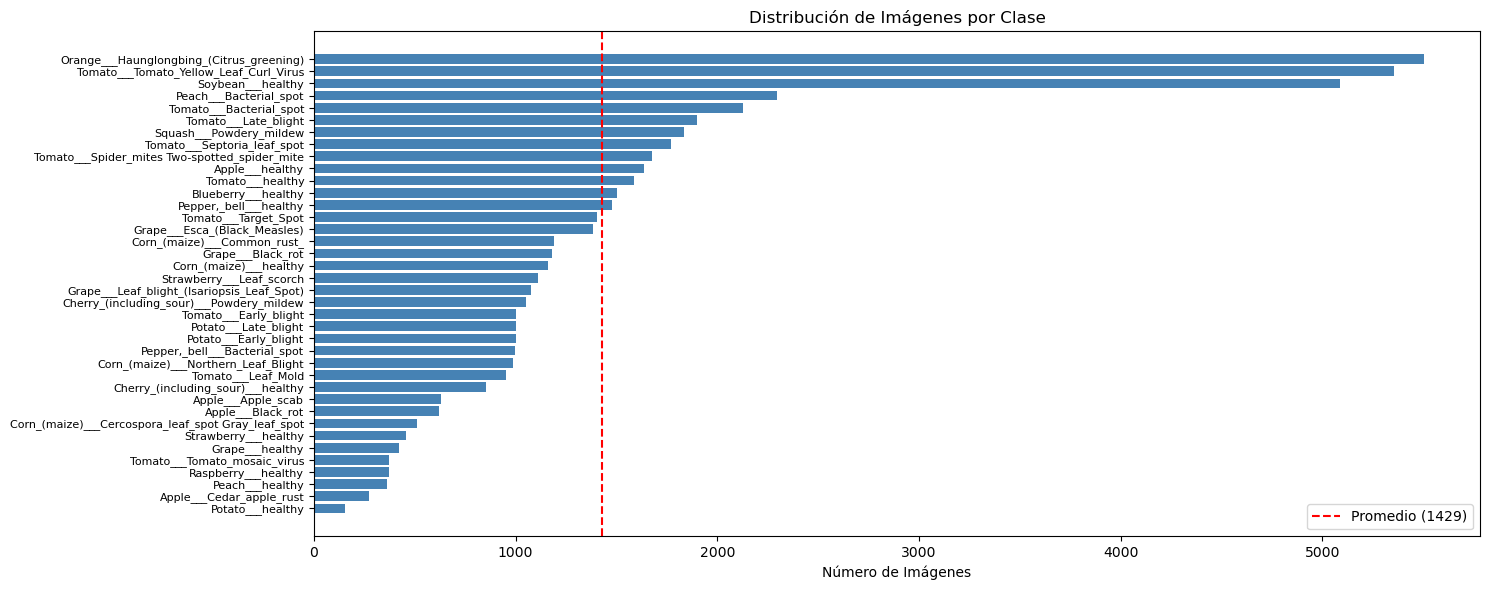


⚠️ Clases con representación baja (< 80% del promedio):
   20 clases requieren augmentation
   Potato___healthy                                  :   152 → necesita ~ 990 imágenes más
   Apple___Cedar_apple_rust                          :   275 → necesita ~ 867 imágenes más
   Peach___healthy                                   :   360 → necesita ~ 782 imágenes más
   Raspberry___healthy                               :   371 → necesita ~ 771 imágenes más
   Tomato___Tomato_mosaic_virus                      :   373 → necesita ~ 769 imágenes más
   Grape___healthy                                   :   423 → necesita ~ 719 imágenes más
   Strawberry___healthy                              :   456 → necesita ~ 686 imágenes más
   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:   513 → necesita ~ 629 imágenes más
   Apple___Black_rot                                 :   621 → necesita ~ 521 imágenes más
   Apple___Apple_scab                                :   630 → necesita ~ 512 imágenes m

In [7]:
def analyze_class_distribution(data_dir):
    """
    Analiza la distribución de imágenes por clase.
    """
    class_counts = {}

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            img_files = [f for f in os.listdir(class_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_counts[class_name] = len(img_files)

    return class_counts

print("="*70)
print("PASO 2: ANÁLISIS DE DISTRIBUCIÓN DE CLASES")
print("="*70)

class_distribution = analyze_class_distribution(data_dir)
total_images = sum(class_distribution.values())
num_classes = len(class_distribution)

print(f"\n📊 Dataset Statistics:")
print(f"   Total de clases: {num_classes}")
print(f"   Total de imágenes: {total_images}")
print(f"   Promedio por clase: {total_images / num_classes:.1f}")

# Ordenar por cantidad de imágenes
sorted_classes = sorted(class_distribution.items(), key=lambda x: x[1])

print(f"\n📉 Top 10 clases con MENOS imágenes:")
for class_name, count in sorted_classes[:10]:
    print(f"   {class_name:50s}: {count:5d} imágenes ({count/total_images*100:.2f}%)")

print(f"\n📈 Top 10 clases con MÁS imágenes:")
for class_name, count in sorted_classes[-10:]:
    print(f"   {class_name:50s}: {count:5d} imágenes ({count/total_images*100:.2f}%)")

# Visualizar distribución
plt.figure(figsize=(15, 6))
classes_sorted = [c[0] for c in sorted_classes]
counts_sorted = [c[1] for c in sorted_classes]

plt.barh(range(len(classes_sorted)), counts_sorted, color='steelblue')
plt.yticks(range(len(classes_sorted)), classes_sorted, fontsize=8)
plt.xlabel('Número de Imágenes')
plt.title('Distribución de Imágenes por Clase')
plt.axvline(x=total_images/num_classes, color='red', linestyle='--',
            label=f'Promedio ({total_images/num_classes:.0f})')
plt.legend()
plt.tight_layout()
plt.show()

# Identificar clases con menos representación (< 80% del promedio)
threshold = 0.8 * (total_images / num_classes)
underrepresented_classes = {c: count for c, count in class_distribution.items()
                           if count < threshold}

print(f"\n⚠️ Clases con representación baja (< 80% del promedio):")
print(f"   {len(underrepresented_classes)} clases requieren augmentation")
for class_name, count in sorted(underrepresented_classes.items(), key=lambda x: x[1]):
    needed = int(threshold - count)
    print(f"   {class_name:50s}: {count:5d} → necesita ~{needed:4d} imágenes más")


## 3. Data Augmentation para Clases Desbalanceadas

Aplicamos augmentation selectivo solo a las clases con menor representación.
Esto balancea el dataset sin sobre-aumentar las clases ya bien representadas.


In [8]:
def create_augmentation_pipeline():
    """
    Crea un pipeline de augmentation. Se aplican: rotación de hasta 20 grados en amabas orientaciones;
    espejado de imagenes (horizontal y vertical); modificacion de brillo, contraste y saturación en un 20%;
    se mueve la imagen aleatoriamente en un 10% (horizontal y verticalmente); recorte aleatorio de entre un 80 y un 100%

    """
    return transforms.Compose([
        transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    ])

def augment_underrepresented_classes(data_dir, class_distribution, target_percentile=0.8):
    """
    Aumenta las clases con menos representación hasta alcanzar un umbral objetivo.

    Args:
        data_dir: Directorio raíz del dataset
        class_distribution: Dict con {clase: cantidad}
        target_percentile: Percentil objetivo (0.8 = 80% del promedio)
    """
    total_images = sum(class_distribution.values())
    num_classes = len(class_distribution)
    target_count = int(target_percentile * (total_images / num_classes))

    augmentation = create_augmentation_pipeline()
    total_generated = 0

    print("="*70)
    print("PASO 3: DATA AUGMENTATION SELECTIVO")
    print("="*70)
    print(f"Objetivo: ~{target_count} imágenes por clase")

    for class_name, current_count in tqdm(class_distribution.items(), desc="Procesando clases"):
        if current_count >= target_count:
            continue  # Clase ya tiene suficientes imágenes

        needed = target_count - current_count
        class_path = os.path.join(data_dir, class_name)

        # Obtener todas las imágenes de esta clase
        img_files = [f for f in os.listdir(class_path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not img_files:
            continue

        # Generar data augmentation
        generated = 0
        while generated < needed:
            # Seleccionar imagen origen aleatoria
            source_img_name = np.random.choice(img_files)
            source_img_path = os.path.join(class_path, source_img_name)

            try:
                # Cargar y aumentar
                img = Image.open(source_img_path).convert('RGB')
                augmented_img = augmentation(img)

                # Guardar con nombre único
                base_name = os.path.splitext(source_img_name)[0]
                aug_name = f"{base_name}_aug_{generated}.jpg"
                aug_path = os.path.join(class_path, aug_name)

                augmented_img.save(aug_path)
                generated += 1
                total_generated += 1

            except Exception as e:
                print(f"Error augmentando {source_img_path}: {e}")
                continue

        print(f"  ✓ {class_name:50s}: +{generated} imágenes ({current_count} → {current_count + generated})")

    print(f"\n✅ Data Augmentation completado: {total_generated} nuevas imágenes generadas")

    return total_generated


PASO 3: DATA AUGMENTATION SELECTIVO
Objetivo: ~1142 imágenes por clase


Procesando clases:   3%|▎         | 1/38 [00:02<01:35,  2.59s/it]

  ✓ Strawberry___healthy                              : +686 imágenes (456 → 1142)


Procesando clases:   8%|▊         | 3/38 [00:03<00:30,  1.13it/s]

  ✓ Potato___Early_blight                             : +142 imágenes (1000 → 1142)


...

  ✓ Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: +629 imágenes (513 → 1142)


Procesando clases:  95%|█████████▍| 36/38 [00:26<00:01,  1.83it/s]

  ✓ Apple___Black_rot                                 : +521 imágenes (621 → 1142)
  ✓ Strawberry___Leaf_scorch                          : +33 imágenes (1109 → 1142)


Procesando clases: 100%|██████████| 38/38 [00:29<00:00,  1.29it/s]

  ✓ Potato___healthy                                  : +990 imágenes (152 → 1142)

✅ Data Augmentation completado: 8641 nuevas imágenes generadas

DISTRIBUCIÓN DESPUÉS DE AUGMENTATION

📊 Nuevas estadísticas:
   Total de imágenes: 62925 (antes: 54284, +8641)
   Promedio por clase: 1655.9


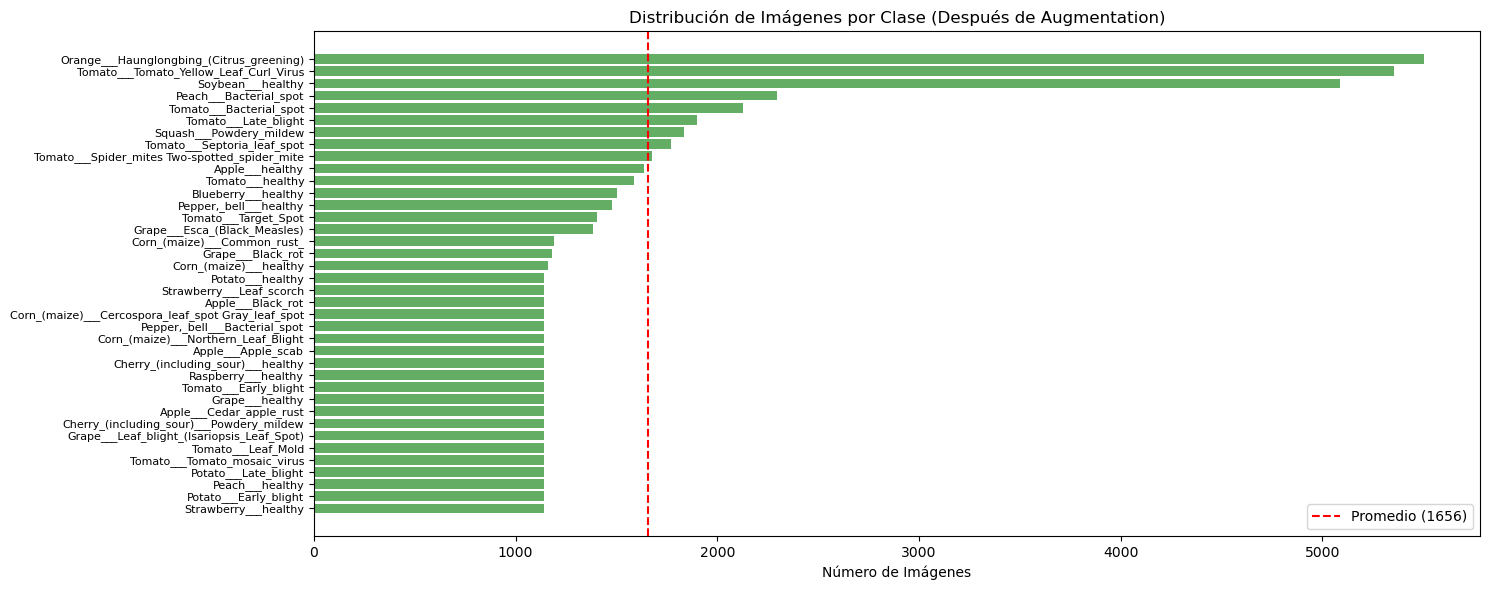

In [9]:
# Ejecutar data augmentation
generated_images = augment_underrepresented_classes(data_dir, class_distribution, target_percentile=0.8)

# Re-analizar distribución después del augmentation
print("\n" + "="*70)
print("DISTRIBUCIÓN DESPUÉS DE AUGMENTATION")
print("="*70)

new_distribution = analyze_class_distribution(data_dir)
new_total = sum(new_distribution.values())

print(f"\n📊 Nuevas estadísticas:")
print(f"   Total de imágenes: {new_total} (antes: {total_images}, +{new_total - total_images})")
print(f"   Promedio por clase: {new_total / num_classes:.1f}")

# Visualizar nueva distribución
plt.figure(figsize=(15, 6))
sorted_new = sorted(new_distribution.items(), key=lambda x: x[1])
classes_new = [c[0] for c in sorted_new]
counts_new = [c[1] for c in sorted_new]

plt.barh(range(len(classes_new)), counts_new, color='forestgreen', alpha=0.7)
plt.yticks(range(len(classes_new)), classes_new, fontsize=8)
plt.xlabel('Número de Imágenes')
plt.title('Distribución de Imágenes por Clase (Después de Augmentation)')
plt.axvline(x=new_total/num_classes, color='red', linestyle='--',
            label=f'Promedio ({new_total/num_classes:.0f})')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Preparación de Datos y Transformaciones


In [10]:
# Transformaciones para train (con augmentation adicional ligero)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Transformaciones para val y test (sin augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


## 5. Partición Estratificada del Dataset


In [11]:
def stratified_split_indices(indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=None):
    """
    Divide los índices de forma estratificada por clase.
    """
    if rng is None:
        rng = np.random.RandomState(0)

    train_idxs, val_idxs, test_idxs = [], [], []

    # Agrupar por clase
    class_to_idxs = {}
    for i in indices:
        class_to_idxs.setdefault(labels[i], []).append(i)

    # Dividir cada clase
    for cls, idxs in class_to_idxs.items():
        idxs = list(idxs)
        rng.shuffle(idxs)
        n = len(idxs)

        n_train = int(train_frac * n)
        n_val = int(val_frac * n)

        train_idxs.extend(idxs[:n_train])
        val_idxs.extend(idxs[n_train:n_train + n_val])
        test_idxs.extend(idxs[n_train + n_val:])

    return train_idxs, val_idxs, test_idxs

# Cargar dataset completo
full_dataset = datasets.ImageFolder(root=data_dir)
labels = [label for _, label in full_dataset.samples]
num_classes = len(full_dataset.classes)

rng = np.random.RandomState(42)

if test_execution:
    # Subset reducido para pruebas
    subset_indices = []
    reduction_factor = 0.1

    for class_idx in range(num_classes):
        class_indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label == class_idx]
        n_samples = max(1, int(len(class_indices) * reduction_factor))
        chosen = rng.choice(class_indices, n_samples, replace=False).tolist()
        subset_indices.extend(chosen)

    rng.shuffle(subset_indices)
    train_indices, val_indices, test_indices = stratified_split_indices(
        subset_indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=rng
    )

    train_dataset = Subset(datasets.ImageFolder(root=data_dir, transform=train_transform), train_indices)
    val_dataset = Subset(datasets.ImageFolder(root=data_dir, transform=val_transform), val_indices)
    test_dataset = Subset(datasets.ImageFolder(root=data_dir, transform=test_transform), test_indices)
else:
    # Dataset completo
    all_indices = list(range(len(full_dataset)))
    train_indices, val_indices, test_indices = stratified_split_indices(
        all_indices, labels, train_frac=0.8, val_frac=0.1, test_frac=0.1, rng=rng
    )

    train_dataset = Subset(full_dataset, train_indices)
    val_dataset = Subset(full_dataset, val_indices)
    test_dataset = Subset(full_dataset, test_indices)

    train_dataset.dataset.transform = train_transform
    val_dataset.dataset.transform = val_transform
    test_dataset.dataset.transform = test_transform

print(f"✅ Dataset preparado:")
print(f"   Clases: {num_classes}")
print(f"   Train: {len(train_dataset)}")
print(f"   Val: {len(val_dataset)}")
print(f"   Test: {len(test_dataset)}")


✅ Dataset preparado:
   Clases: 38
   Train: 5015
   Val: 611
   Test: 655


## 5.1 Técnicas de Balanceo del Dataset

Implementamos dos técnicas no arbitrarias para manejar el desbalance de clases:

1. **WeightedRandomSampler**: Muestrea aleatoriamente el dataset dando mayor probabilidad a las clases menos representadas, uniformando la distribución durante el entrenamiento.

2. **Pesos por clase en la función de costo**: Penaliza los errores en las clases menos pobladas, haciendo que el modelo les preste más atención.

Ambas técnicas son complementarias y se pueden usar juntas o por separado.


In [12]:
def compute_class_weights(dataset, num_classes):
    """
    Calcula los pesos por clase inversamente proporcionales a su frecuencia.
    Útil para CrossEntropyLoss con weight parameter.
    
    Args:
        dataset: Dataset o Subset de PyTorch
        num_classes: Número de clases
    
    Returns:
        torch.Tensor con los pesos por clase
    """
    # Obtener labels del dataset
    if isinstance(dataset, Subset):
        labels = [dataset.dataset.targets[i] for i in dataset.indices]
    else:
        labels = [label for _, label in dataset.samples]
    
    # Contar frecuencia de cada clase
    class_counts = Counter(labels)
    
    # Calcular peso inversamente proporcional a la frecuencia
    # weight_i = total_samples / (num_classes * count_i)
    total_samples = len(labels)
    weights = []
    
    for class_idx in range(num_classes):
        count = class_counts.get(class_idx, 1)  # Evitar división por cero
        weight = total_samples / (num_classes * count)
        weights.append(weight)
    
    return torch.FloatTensor(weights)


def compute_sample_weights(dataset, num_classes):
    """
    Calcula el peso de cada muestra basado en la frecuencia inversa de su clase.
    Útil para WeightedRandomSampler.
    
    Args:
        dataset: Dataset o Subset de PyTorch
        num_classes: Número de clases
    
    Returns:
        torch.Tensor con el peso de cada muestra
    """
    # Obtener labels del dataset
    if isinstance(dataset, Subset):
        labels = [dataset.dataset.targets[i] for i in dataset.indices]
    else:
        labels = [label for _, label in dataset.samples]
    
    # Contar frecuencia de cada clase
    class_counts = Counter(labels)
    
    # Calcular peso por clase (inversamente proporcional a frecuencia)
    class_weights = {}
    for class_idx in range(num_classes):
        count = class_counts.get(class_idx, 1)
        class_weights[class_idx] = 1.0 / count
    
    # Asignar peso a cada muestra según su clase
    sample_weights = [class_weights[label] for label in labels]
    
    return torch.DoubleTensor(sample_weights)


def create_weighted_sampler(dataset, num_classes):
    """
    Crea un WeightedRandomSampler para balancear el muestreo durante el entrenamiento.
    
    Args:
        dataset: Dataset o Subset de PyTorch
        num_classes: Número de clases
    
    Returns:
        WeightedRandomSampler configurado
    """
    sample_weights = compute_sample_weights(dataset, num_classes)
    
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True  # Con reemplazo para permitir sobremuestreo de clases minoritarias
    )
    
    return sampler


# Calcular y mostrar los class weights
print("="*70)
print("CÁLCULO DE PESOS PARA BALANCEO DE CLASES")
print("="*70)

# Class weights para CrossEntropyLoss
class_weights = compute_class_weights(train_dataset, num_classes)
print("\n📊 Class Weights para CrossEntropyLoss:")
print(f"   Min weight: {class_weights.min().item():.4f}")
print(f"   Max weight: {class_weights.max().item():.4f}")
print(f"   Mean weight: {class_weights.mean().item():.4f}")

# Mostrar algunas clases con más y menos peso
sorted_weights = sorted(enumerate(class_weights.tolist()), key=lambda x: x[1])
print("\n📉 Top 5 clases con MENOR peso (más muestras):")
for idx, weight in sorted_weights[:5]:
    class_name = full_dataset.classes[idx]
    print(f"   {class_name:50s}: {weight:.4f}")

print("\n📈 Top 5 clases con MAYOR peso (menos muestras):")
for idx, weight in sorted_weights[-5:]:
    class_name = full_dataset.classes[idx]
    print(f"   {class_name:50s}: {weight:.4f}")

# Sample weights para WeightedRandomSampler
sample_weights_train = compute_sample_weights(train_dataset, num_classes)
print(f"\n📊 Sample Weights para WeightedRandomSampler:")
print(f"   Total de muestras: {len(sample_weights_train)}")
print(f"   Min sample weight: {sample_weights_train.min().item():.6f}")
print(f"   Max sample weight: {sample_weights_train.max().item():.6f}")

# Crear sampler para verificar
weighted_sampler_train = create_weighted_sampler(train_dataset, num_classes)
print(f"\n✅ WeightedRandomSampler creado con {len(sample_weights_train)} muestras")
print("="*70)


CÁLCULO DE PESOS PARA BALANCEO DE CLASES

📊 Class Weights para CrossEntropyLoss:
   Min weight: 0.2999
   Max weight: 1.4503
   Mean weight: 1.2115

📉 Top 5 clases con MENOR peso (más muestras):
   Orange___Haunglongbing_(Citrus_greening)          : 0.2999
   Tomato___Tomato_Yellow_Leaf_Curl_Virus            : 0.3083
   Soybean___healthy                                 : 0.3243
   Peach___Bacterial_spot                            : 0.7212
   Tomato___Bacterial_spot                           : 0.7809

📈 Top 5 clases con MAYOR peso (menos muestras):
   Strawberry___Leaf_scorch                          : 1.4503
   Strawberry___healthy                              : 1.4503
   Tomato___Early_blight                             : 1.4503
   Tomato___Leaf_Mold                                : 1.4503
   Tomato___Tomato_mosaic_virus                      : 1.4503

📊 Sample Weights para WeightedRandomSampler:
   Total de muestras: 5015
   Min sample weight: 0.002273
   Max sample weight: 0.010989



## 6. Funciones de Utilidad: Training y Evaluación


In [13]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=5, patience=3, device='cuda'):
    """
    Entrena un modelo con early stopping.
    """
    since = time.time()

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_recall': [], 'val_recall': [],
        'train_f1': [], 'val_f1': [],
        'train_auc_pr': [], 'val_auc_pr': []
    }

    model.to(device)
    best_metric = -np.inf
    counter = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            all_labels = []
            all_preds = []
            all_probs = []

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    probs = torch.softmax(outputs, dim=1)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.append(probs.detach().cpu().numpy())

            all_probs = np.vstack(all_probs)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = accuracy_score(all_labels, all_preds)
            epoch_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
            epoch_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
            auc_pr = average_precision_score(all_labels, all_probs, average='macro')

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} '
                  f'Recall: {epoch_recall:.4f} F1: {epoch_f1:.4f} AUC-PR: {auc_pr:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
                history['train_recall'].append(epoch_recall)
                history['train_f1'].append(epoch_f1)
                history['train_auc_pr'].append(auc_pr)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                history['val_recall'].append(epoch_recall)
                history['val_f1'].append(epoch_f1)
                history['val_auc_pr'].append(auc_pr)

        # Early stopping
        epoch_metric = history['val_auc_pr'][-1]  # Usamos F1 como métrica principal

        if epoch_metric > best_metric:
            best_metric = epoch_metric
            counter = 0
            best_model_wts = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping en epoch {epoch+1}")
                break

    time_elapsed = time.time() - since
    print(f'\nEntrenamiento completado en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Mejor AUC PR validation: {best_metric:.4f}')

    # Cargar los mejores pesos
    model.load_state_dict(best_model_wts)

    return model, history, time_elapsed


def evaluate_model(model, dataloader, device='cpu'):
    """
    Evalúa un modelo en un conjunto de datos.
    """
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    start_time = time.time()

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    inference_time = time.time() - start_time
    all_probs = np.vstack(all_probs)

    accuracy = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    auc_pr = average_precision_score(all_labels, all_probs, average='macro')

    return accuracy, recall, f1, auc_pr, inference_time


def get_model_size(model, model_name="model"):
    """
    Calcula el tamaño del modelo en disco.
    """
    torch.save(model.state_dict(), f"{model_name}.pth")
    size_mb = os.path.getsize(f"{model_name}.pth") / 1e6
    os.remove(f"{model_name}.pth")
    return size_mb


def plot_history(history, title="Training History"):
    """
    Grafica las métricas de entrenamiento.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    metrics = [('loss', 'Loss'), ('acc', 'Accuracy'), ('recall', 'Recall'),
               ('f1', 'F1 Score'), ('auc_pr', 'AUC-PR')]

    for idx, (metric, label) in enumerate(metrics):
        row = idx // 3
        col = idx % 3

        axes[row, col].plot(history[f'train_{metric}'], label='Train', marker='o')
        axes[row, col].plot(history[f'val_{metric}'], label='Validation', marker='s')
        axes[row, col].set_xlabel('Epoch')
        axes[row, col].set_ylabel(label)
        axes[row, col].set_title(f'{label} Over Time')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)

    # Ocultar el último subplot vacío
    axes[1, 2].axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


## 7. Búsqueda de Hiperparámetros con Optuna

Utilizamos Optuna para encontrar los mejores hiperparámetros:
- Learning rate
- Batch size
- Arquitectura del clasificador (número de capas y neuronas)
- Optimizer (SGD vs Adam)
- Weight decay

**Nota:** Para acelerar la búsqueda, usamos solo el **30% del dataset** en los trials de Optuna.


#### Funciones

In [14]:
# Crear subsets del 30% para búsqueda de hiperparámetros (acelera el proceso)
print("="*70)
print("PREPARANDO SUBSETS PARA BÚSQUEDA DE HIPERPARÁMETROS")
print("="*70)

subset_fraction = 0.3  # Usar 30% del dataset

# Obtener labels de los datasets
if isinstance(train_dataset, Subset):
    train_labels = [train_dataset.dataset.targets[i] for i in train_dataset.indices]
    val_labels = [val_dataset.dataset.targets[i] for i in val_dataset.indices]
else:
    train_labels = [label for _, label in train_dataset.samples]
    val_labels = [label for _, label in val_dataset.samples]

# Crear subsets estratificados del 30%
def create_stratified_subset(dataset, labels, fraction, rng):
    """Crea un subset estratificado por clase."""
    class_to_idxs = {}
    for i, label in enumerate(labels):
        class_to_idxs.setdefault(label, []).append(i)

    subset_indices = []
    for class_label, indices in class_to_idxs.items():
        n_samples = max(1, int(len(indices) * fraction))
        chosen = rng.choice(indices, n_samples, replace=False).tolist()
        subset_indices.extend(chosen)

    rng.shuffle(subset_indices)
    return subset_indices

rng_optuna = np.random.RandomState(42)

# Crear índices para subsets
train_subset_indices = create_stratified_subset(train_dataset, train_labels, subset_fraction, rng_optuna)
val_subset_indices = create_stratified_subset(val_dataset, val_labels, subset_fraction, rng_optuna)

# Crear los subsets
if isinstance(train_dataset, Subset):
    # Si ya es un Subset, necesitamos mapear los índices
    train_optuna_indices = [train_dataset.indices[i] for i in train_subset_indices]
    val_optuna_indices = [val_dataset.indices[i] for i in val_subset_indices]

    train_dataset_optuna = Subset(train_dataset.dataset, train_optuna_indices)
    val_dataset_optuna = Subset(val_dataset.dataset, val_optuna_indices)
else:
    train_dataset_optuna = Subset(train_dataset, train_subset_indices)
    val_dataset_optuna = Subset(val_dataset, val_subset_indices)

print(f"\n✅ Subsets creados para Optuna:")
print(f"   Train subset: {len(train_dataset_optuna)} imágenes ({len(train_dataset_optuna)/len(train_dataset)*100:.1f}% del original)")
print(f"   Val subset: {len(val_dataset_optuna)} imágenes ({len(val_dataset_optuna)/len(val_dataset)*100:.1f}% del original)")
print("="*70)


PREPARANDO SUBSETS PARA BÚSQUEDA DE HIPERPARÁMETROS

✅ Subsets creados para Optuna:
   Train subset: 1491 imágenes (29.7% del original)
   Val subset: 169 imágenes (27.7% del original)


In [15]:
def create_model_with_custom_classifier(model, num_classes, hidden_dim=512, num_layers=1, dropout=0.2):
    """
    Crea un modelo preentrenado con clasificador.
    """

    in_features = None
    for layer in model.classifier:
        if isinstance(layer, nn.Linear):
            in_features = layer.in_features
            break

    if in_features is None:
        raise ValueError("No se encontró capa Linear en model.classifier")

    # Congelar features
    for param in model.features.parameters():
        param.requires_grad = False

    # Crear capa de clasificador
    #in_features = model.classifier[1].in_features

    if num_layers == 1:
        model.classifier = nn.Sequential(
            nn.Linear(in_features, num_classes)
        )
    elif num_layers == 2:
        model.classifier = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )
    else:  # 3 layers
        model.classifier = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    return model


def objective(trial, modelo_preentrenado, train_dataset, val_dataset):
    """
    Función objetivo para Optuna.
    Usa un subset para acelerar la búsqueda.
    Incluye técnicas de balanceo: WeightedRandomSampler y class weights.
    """
    print(f"Trial {trial.number} iniciado")

    # Hiperparámetros a optimizar
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    hidden_dim = trial.suggest_categorical('hidden_dim', [256, 512, 1024])
    num_layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    optimizer_name = trial.suggest_categorical('optimizer', ['SGD', 'Adam'])
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    # TÉCNICA DE BALANCEO 1: WeightedRandomSampler para el subset de entrenamiento
    trial_sampler = create_weighted_sampler(train_dataset, num_classes)
    
    # Crear dataloaders con el batch_size sugerido usando los SUBSETS
    trial_dataloaders = {
        'train': DataLoader(train_dataset, batch_size=batch_size, 
                          sampler=trial_sampler,  # Usar sampler en lugar de shuffle
                          num_workers=5, prefetch_factor=2, pin_memory=True,
                            persistent_workers=False),
        'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=5, prefetch_factor=2, pin_memory=True,
                          persistent_workers=False)
    }

    # Crear modelo
    model = create_model_with_custom_classifier(
        model=modelo_preentrenado,
        num_classes=num_classes,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout
    )

    # TÉCNICA DE BALANCEO 2: Pesos por clase en la función de costo
    trial_class_weights = compute_class_weights(train_dataset, num_classes)
    criterion = nn.CrossEntropyLoss(weight=trial_class_weights.to(device))

    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.classifier.parameters(), lr=lr,
                            momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam(model.classifier.parameters(), lr=lr,
                             weight_decay=weight_decay)

    # Entrenar por pocas épocas para evaluar rápido
    model.to(device)
    model.train()

    num_epochs_trial = 5  # Pocas épocas para cada trial

    for epoch in range(num_epochs_trial):
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            all_labels = []
            all_preds = []
            all_probs = []

            for inputs, labels in trial_dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    probs = torch.softmax(outputs, dim=1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.append(probs.detach().cpu().numpy())

        all_probs = np.vstack(all_probs)

        # Calcular F1 en validación
        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        val_auc_pr = average_precision_score(all_labels, all_probs, average='macro')

        # Reportar resultado intermedio
        #trial.report(val_f1, epoch)
        trial.report(val_auc_pr, epoch)

        # Podar trials que no sean prometedores
        if trial.should_prune():
            raise optuna.TrialPruned()

    #return val_f1  # Retornar F1 final de validación
    return val_auc_pr # Retornar AUC PR final de validación


In [16]:
def run_optuna_search(
    modelo_preentrenado,
    objective,
    train_dataset_optuna,
    val_dataset_optuna,
    subset_fraction=0.3,
    n_trials=10,
    seed=42
):
    print("="*70)
    print(f"BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA ({subset_fraction*100}% del dataset)")
    print("="*70)

    # Crear estudio
    study = optuna.create_study(
        direction='maximize',  # Optimizar AUC PR
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=3,
            n_warmup_steps=2
        ),
        sampler=optuna.samplers.TPESampler(seed=seed)
    )

    # Aviso
    print(f"\n🔍 Ejecutando {n_trials} trials de optimización...")
    print(f"   Usando {len(train_dataset_optuna)} imágenes de train "
          f"({subset_fraction*100:.0f}% del total)")
    print(f"   Usando {len(val_dataset_optuna)} imágenes de validación "
          f"({subset_fraction*100:.0f}% del total)")

    # 👉 Pasar el modelo mediante lambda
    study.optimize(
        lambda trial: objective(
            trial,
            modelo_preentrenado=modelo_preentrenado,
            train_dataset=train_dataset_optuna,
            val_dataset=val_dataset_optuna
        ),
        n_trials=n_trials,
        show_progress_bar=True
    )

    # Mostrar resultados
    print("\n" + "="*70)
    print("RESULTADOS DE LA OPTIMIZACIÓN")
    print("="*70)

    print(f"\n🏆 Mejor AUC PR: {study.best_value:.4f}")
    print(f"\n📋 Mejores hiperparámetros:")
    for key, value in study.best_params.items():
        print(f"   {key:15s}: {value}")

    # Importancia de parámetros
    try:
        fig = optuna.visualization.plot_param_importances(study)
        fig.show()
    except:
        print("\n⚠️ No se pudo generar gráfico de importancia (requiere plotly)")

    # Historial
    try:
        fig = optuna.visualization.plot_optimization_history(study)
        fig.show()
    except:
        print("⚠️ No se pudo generar gráfico de historia")

    print(f"\n✅ Hiperparámetros óptimos guardados")
    print(f"\n💡 Nota: Estos hiperparámetros fueron encontrados usando {subset_fraction*100:.0f}% del dataset.")

    return study.best_params, study


#### Búsqueda

In [ ]:
best_params_v2, study_v2 = run_optuna_search(
    modelo_preentrenado = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1),
    objective = objective,
    train_dataset_optuna = train_dataset_optuna,
    val_dataset_optuna = val_dataset_optuna,
    subset_fraction = 0.3,
    n_trials=30,
    seed = 100
)

[I 2025-12-14 17:15:49,414] A new study created in memory with name: no-name-0aed3380-2d42-4d9b-8bbd-18a14086898e


BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (30.0% del dataset)

🔍 Ejecutando 30 trials de optimización...
   Usando 1491 imágenes de train (30% del total)
   Usando 169 imágenes de validación (30% del total)


  0%|          | 0/30 [00:00<?, ?it/s]

Trial 0 iniciado


``` [I 2025-12-13 16:02:01,632] A new study created in memory with name: no-name-7c62a7c3-b34d-453d-9c77-d0091bd00bdf
======================================================================
BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (30.0% del dataset)
======================================================================

🔍 Ejecutando 30 trials de optimización...
   Usando 16055 imágenes de train (30% del total)
   Usando 1986 imágenes de validación (30% del total)
Best trial: 19. Best value: 0.989366: 100%
 30/30 [23:55<00:00, 43.92s/it]
Trial 0 iniciado
[I 2025-12-13 16:02:56,346] Trial 0 finished with value: 0.9758617363586141 and parameters: {'lr': 0.004267905801362681, 'batch_size': 128, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.3300373317709, 'optimizer': 'SGD', 'weight_decay': 3.597366273200832e-06}. Best is trial 0 with value: 0.9758617363586141.
Trial 1 iniciado
[I 2025-12-13 16:03:50,895] Trial 1 finished with value: 0.3884012194852325 and parameters: {'lr': 0.0002114125046324832, 'batch_size': 64, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.427059751510691, 'optimizer': 'SGD', 'weight_decay': 1.3136998153536435e-05}. Best is trial 0 with value: 0.9758617363586141.
Trial 2 iniciado
[I 2025-12-13 16:04:44,331] Trial 2 finished with value: 0.797948508720902 and parameters: {'lr': 0.00010400770705381915, 'batch_size': 64, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.45616462537683033, 'optimizer': 'SGD', 'weight_decay': 0.00046950241897640484}. Best is trial 0 with value: 0.9758617363586141.
Trial 3 iniciado
[I 2025-12-13 16:05:41,236] Trial 3 finished with value: 0.978444623694507 and parameters: {'lr': 0.005379036586189748, 'batch_size': 32, 'hidden_dim': 1024, 'num_layers': 1, 'dropout': 0.2143582761627459, 'optimizer': 'Adam', 'weight_decay': 0.00045139825979066656}. Best is trial 3 with value: 0.978444623694507.
Trial 4 iniciado
[I 2025-12-13 16:06:36,799] Trial 4 finished with value: 0.9756949675995369 and parameters: {'lr': 0.0011981840438312792, 'batch_size': 32, 'hidden_dim': 1024, 'num_layers': 2, 'dropout': 0.3371221603903547, 'optimizer': 'SGD', 'weight_decay': 0.0006331752031792306}. Best is trial 3 with value: 0.978444623694507.
Trial 5 iniciado
[I 2025-12-13 16:07:10,362] Trial 5 pruned.
Trial 6 iniciado
[I 2025-12-13 16:07:46,066] Trial 6 pruned.
Trial 7 iniciado
[I 2025-12-13 16:08:22,574] Trial 7 pruned.
Trial 8 iniciado
[I 2025-12-13 16:08:55,766] Trial 8 pruned.
Trial 9 iniciado
[I 2025-12-13 16:09:55,678] Trial 9 finished with value: 0.9833883703129155 and parameters: {'lr': 0.0006538717095064104, 'batch_size': 256, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.26115213255165687, 'optimizer': 'Adam', 'weight_decay': 2.1653588859384835e-05}. Best is trial 9 with value: 0.9833883703129155.
Trial 10 iniciado
[I 2025-12-13 16:10:54,946] Trial 10 finished with value: 0.9856580109098834 and parameters: {'lr': 0.0006445476213367157, 'batch_size': 256, 'hidden_dim': 512, 'num_layers': 2, 'dropout': 0.11087822940735276, 'optimizer': 'Adam', 'weight_decay': 0.00010986174480302296}. Best is trial 10 with value: 0.9856580109098834.
Trial 11 iniciado
[I 2025-12-13 16:11:53,911] Trial 11 finished with value: 0.9845816452727266 and parameters: {'lr': 0.000652083602281137, 'batch_size': 256, 'hidden_dim': 512, 'num_layers': 2, 'dropout': 0.10385201636715788, 'optimizer': 'Adam', 'weight_decay': 0.00012351902098745295}. Best is trial 10 with value: 0.9856580109098834.
Trial 12 iniciado
[I 2025-12-13 16:12:53,661] Trial 12 finished with value: 0.9843374638889505 and parameters: {'lr': 0.000510536546466453, 'batch_size': 256, 'hidden_dim': 512, 'num_layers': 2, 'dropout': 0.10994462036397379, 'optimizer': 'Adam', 'weight_decay': 0.0001302110806042588}. Best is trial 10 with value: 0.9856580109098834.
Trial 13 iniciado
[I 2025-12-13 16:13:53,335] Trial 13 finished with value: 0.9828357438833167 and parameters: {'lr': 0.0018598152665817676, 'batch_size': 256, 'hidden_dim': 512, 'num_layers': 2, 'dropout': 0.10067741874438797, 'optimizer': 'Adam', 'weight_decay': 0.00011636786812404187}. Best is trial 10 with value: 0.9856580109098834.
Trial 14 iniciado
[I 2025-12-13 16:14:29,625] Trial 14 pruned.
Trial 15 iniciado
[I 2025-12-13 16:15:05,401] Trial 15 pruned.
Trial 16 iniciado
[I 2025-12-13 16:16:04,760] Trial 16 finished with value: 0.9863628258816395 and parameters: {'lr': 0.0020612572765901778, 'batch_size': 256, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.23025277026515611, 'optimizer': 'Adam', 'weight_decay': 0.00019767792034452457}. Best is trial 16 with value: 0.9863628258816395.
Trial 17 iniciado
[I 2025-12-13 16:16:59,181] Trial 17 finished with value: 0.9872640663021199 and parameters: {'lr': 0.0019416680688624185, 'batch_size': 64, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.21824780030593008, 'optimizer': 'Adam', 'weight_decay': 0.0002471755198007596}. Best is trial 17 with value: 0.9872640663021199.
Trial 18 iniciado
[I 2025-12-13 16:17:31,746] Trial 18 pruned.
Trial 19 iniciado
[I 2025-12-13 16:18:25,024] Trial 19 finished with value: 0.9893661965766997 and parameters: {'lr': 0.0021413341205744167, 'batch_size': 64, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.22613400786478782, 'optimizer': 'Adam', 'weight_decay': 0.00024393465462152218}. Best is trial 19 with value: 0.9893661965766997.
Trial 20 iniciado
[I 2025-12-13 16:18:57,908] Trial 20 pruned.
Trial 21 iniciado
[I 2025-12-13 16:19:51,359] Trial 21 finished with value: 0.9876164680339997 and parameters: {'lr': 0.0024052704465252167, 'batch_size': 64, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.21886114842467874, 'optimizer': 'Adam', 'weight_decay': 0.00022579801819629339}. Best is trial 19 with value: 0.9893661965766997.
Trial 22 iniciado
[I 2025-12-13 16:20:34,038] Trial 22 pruned.
Trial 23 iniciado
[I 2025-12-13 16:21:27,585] Trial 23 finished with value: 0.9852377352003052 and parameters: {'lr': 0.0026779506939213463, 'batch_size': 64, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.15634285278257448, 'optimizer': 'Adam', 'weight_decay': 0.0002620724972686972}. Best is trial 19 with value: 0.9893661965766997.
Trial 24 iniciado
[I 2025-12-13 16:22:20,255] Trial 24 finished with value: 0.9884309520424289 and parameters: {'lr': 0.0014307773160312418, 'batch_size': 64, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.2347480312989435, 'optimizer': 'Adam', 'weight_decay': 6.04124892685009e-05}. Best is trial 19 with value: 0.9893661965766997.
Trial 25 iniciado
[I 2025-12-13 16:23:03,301] Trial 25 pruned.
Trial 26 iniciado
[I 2025-12-13 16:23:35,575] Trial 26 pruned.
Trial 27 iniciado
[I 2025-12-13 16:24:28,842] Trial 27 finished with value: 0.9877397105376348 and parameters: {'lr': 0.0012114694171396956, 'batch_size': 64, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.36603190338970554, 'optimizer': 'Adam', 'weight_decay': 0.00038884801928987185}. Best is trial 19 with value: 0.9893661965766997.
Trial 28 iniciado
[I 2025-12-13 16:25:23,901] Trial 28 finished with value: 0.9864278791486698 and parameters: {'lr': 0.0011422420273558692, 'batch_size': 128, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.3749741964873537, 'optimizer': 'Adam', 'weight_decay': 0.0009462961872479104}. Best is trial 19 with value: 0.9893661965766997.
Trial 29 iniciado
[I 2025-12-13 16:25:56,648] Trial 29 pruned.

======================================================================
RESULTADOS DE LA OPTIMIZACIÓN
======================================================================

🏆 Mejor AUC PR: 0.9894

📋 Mejores hiperparámetros:
   lr             : 0.0021413341205744167
   batch_size     : 64
   hidden_dim     : 512
   num_layers     : 1
   dropout        : 0.22613400786478782
   optimizer      : Adam
   weight_decay   : 0.00024393465462152218
```

In [17]:
best_params_v2 = {
    'lr': 0.0021413341205744167,
    'batch_size': 64,
    'hidden_dim': 512,
    'num_layers': 1,
    'dropout': 0.22613400786478782,
    'optimizer': 'Adam',
    'weight_decay': 0.00024393465462152218
}

In [ ]:
best_params_v3, study_v3 = run_optuna_search(
    modelo_preentrenado = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1),
    objective = objective,
    train_dataset_optuna = train_dataset_optuna,
    val_dataset_optuna = val_dataset_optuna,
    subset_fraction = 0.3,
    n_trials=30,
    seed = 142
)

```Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 223MB/s]
[I 2025-12-13 16:25:59,647] A new study created in memory with name: no-name-3909a3fc-8494-4fb5-8cf3-0c2380d946cb
======================================================================
BÚSQUEDA DE HIPERPARÁMETROS CON OPTUNA (30.0% del dataset)
======================================================================

🔍 Ejecutando 30 trials de optimización...
   Usando 16055 imágenes de train (30% del total)
   Usando 1986 imágenes de validación (30% del total)
Best trial: 22. Best value: 0.986397: 100%
 30/30 [19:52<00:00, 35.06s/it]
Trial 0 iniciado
[I 2025-12-13 16:26:55,836] Trial 0 finished with value: 0.9841917104324791 and parameters: {'lr': 0.050837545538366405, 'batch_size': 128, 'hidden_dim': 512, 'num_layers': 2, 'dropout': 0.4134573480244629, 'optimizer': 'SGD', 'weight_decay': 2.2148279502168874e-06}. Best is trial 0 with value: 0.9841917104324791.
Trial 1 iniciado
[I 2025-12-13 16:27:50,181] Trial 1 finished with value: 0.9763273312151233 and parameters: {'lr': 0.0009944080855655755, 'batch_size': 64, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.1313420967311051, 'optimizer': 'Adam', 'weight_decay': 4.5594291242577666e-05}. Best is trial 0 with value: 0.9841917104324791.
Trial 2 iniciado
[I 2025-12-13 16:28:46,381] Trial 2 finished with value: 0.986307163211248 and parameters: {'lr': 0.03679615746746246, 'batch_size': 32, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.402987720014651, 'optimizer': 'SGD', 'weight_decay': 0.0003685920818608935}. Best is trial 2 with value: 0.986307163211248.
Trial 3 iniciado
[I 2025-12-13 16:29:20,019] Trial 3 pruned.
Trial 4 iniciado
[I 2025-12-13 16:30:16,086] Trial 4 pruned.
Trial 5 iniciado
[I 2025-12-13 16:30:49,485] Trial 5 pruned.
Trial 6 iniciado
[I 2025-12-13 16:31:22,221] Trial 6 pruned.
Trial 7 iniciado
[I 2025-12-13 16:31:56,047] Trial 7 pruned.
Trial 8 iniciado
[I 2025-12-13 16:32:31,012] Trial 8 pruned.
Trial 9 iniciado
[I 2025-12-13 16:33:03,673] Trial 9 pruned.
Trial 10 iniciado
[I 2025-12-13 16:33:37,166] Trial 10 pruned.
Trial 11 iniciado
[I 2025-12-13 16:34:33,261] Trial 11 finished with value: 0.9853022981938178 and parameters: {'lr': 0.0780668794758245, 'batch_size': 32, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.35703108057214267, 'optimizer': 'SGD', 'weight_decay': 0.00014093620955588695}. Best is trial 2 with value: 0.986307163211248.
Trial 12 iniciado
[I 2025-12-13 16:35:07,120] Trial 12 pruned.
Trial 13 iniciado
[I 2025-12-13 16:35:40,950] Trial 13 pruned.
Trial 14 iniciado
[I 2025-12-13 16:36:15,425] Trial 14 pruned.
Trial 15 iniciado
[I 2025-12-13 16:36:51,008] Trial 15 pruned.
Trial 16 iniciado
[I 2025-12-13 16:37:47,310] Trial 16 finished with value: 0.9856382771969268 and parameters: {'lr': 0.09964798126238197, 'batch_size': 32, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.27025654530490434, 'optimizer': 'SGD', 'weight_decay': 6.778489601863071e-05}. Best is trial 2 with value: 0.986307163211248.
Trial 17 iniciado
[I 2025-12-13 16:38:20,703] Trial 17 pruned.
Trial 18 iniciado
[I 2025-12-13 16:38:54,477] Trial 18 pruned.
Trial 19 iniciado
[I 2025-12-13 16:39:29,890] Trial 19 pruned.
Trial 20 iniciado
[I 2025-12-13 16:40:03,692] Trial 20 pruned.
Trial 21 iniciado
[I 2025-12-13 16:40:37,209] Trial 21 pruned.
Trial 22 iniciado
[I 2025-12-13 16:41:33,360] Trial 22 finished with value: 0.9863972144747252 and parameters: {'lr': 0.059329444680960054, 'batch_size': 32, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.4225091797371915, 'optimizer': 'SGD', 'weight_decay': 0.0001771479661600252}. Best is trial 22 with value: 0.9863972144747252.
Trial 23 iniciado
[I 2025-12-13 16:42:29,407] Trial 23 pruned.
Trial 24 iniciado
[I 2025-12-13 16:43:03,109] Trial 24 pruned.
Trial 25 iniciado
[I 2025-12-13 16:43:36,720] Trial 25 pruned.
Trial 26 iniciado
[I 2025-12-13 16:44:10,616] Trial 26 pruned.
Trial 27 iniciado
[I 2025-12-13 16:44:46,279] Trial 27 pruned.
Trial 28 iniciado
[I 2025-12-13 16:45:18,106] Trial 28 pruned.
Trial 29 iniciado
[I 2025-12-13 16:45:51,840] Trial 29 pruned.

======================================================================
RESULTADOS DE LA OPTIMIZACIÓN
======================================================================

🏆 Mejor AUC PR: 0.9864

📋 Mejores hiperparámetros:
   lr             : 0.059329444680960054
   batch_size     : 32
   hidden_dim     : 512
   num_layers     : 1
   dropout        : 0.4225091797371915
   optimizer      : SGD
   weight_decay   : 0.0001771479661600252
   ```

In [19]:
best_params_v3 = {
    'lr': 0.059329444680960054,
    'batch_size': 32,
    'hidden_dim': 512,
    'num_layers': 1,
    'dropout': 0.4225091797371915,
    'optimizer': 'Adam',
    'weight_decay': 0.0001771479661600252
}

## Entrenamientos con hoperparámetros óptimos

### 8.1 Modelo 1: MobileNetV2 Optimizado


In [ ]:
# Crear dataloaders con el mejor batch_size encontrado por Optuna
# IMPORTANTE: Usamos los datasets COMPLETOS (train_dataset, val_dataset, test_dataset)
# NO los subsets del 30% que usamos para la búsqueda
# 
# TÉCNICA DE BALANCEO 1: WeightedRandomSampler
# Usamos WeightedRandomSampler en lugar de shuffle=True para balancear el muestreo
optimal_batch_size = best_params_v2['batch_size']

# Crear WeightedRandomSampler para el dataset de entrenamiento
weighted_sampler_v2 = create_weighted_sampler(train_dataset, num_classes)

dataloaders_v2 = {
    'train': DataLoader(train_dataset, batch_size=optimal_batch_size, 
                    sampler=weighted_sampler_v2,  # Usar sampler en lugar de shuffle
                    num_workers=5, prefetch_factor=2, pin_memory=True,
                    persistent_workers=True, pin_memory_device="cuda"),
    'val': DataLoader(val_dataset, batch_size=optimal_batch_size, shuffle=False,
                     num_workers=5, prefetch_factor=2, pin_memory=True,
                  persistent_workers=True, pin_memory_device="cuda"),
    'test': DataLoader(test_dataset, batch_size=optimal_batch_size, shuffle=False,
                  num_workers=5, prefetch_factor=2, pin_memory=True,
                  persistent_workers=True, pin_memory_device="cuda")
}

print(f"✅ Dataloaders creados con batch_size={optimal_batch_size}")
print(f"   Train: {len(dataloaders_v2['train'])} batches (con WeightedRandomSampler)")
print(f"   Val: {len(dataloaders_v2['val'])} batches")
print(f"   Test: {len(dataloaders_v2['test'])} batches")


✅ Dataloaders creados con batch_size=64
   Train: 838 imágenes (100% del dataset)
   Val: 105 imágenes (100% del dataset)
   Test: 106 imágenes (100% del dataset)


ENTRENANDO MODELO 1: MobileNetV2 Optimizado
Epoch 1/30
----------
train Loss: 0.3114 Acc: 0.9185 Recall: 0.9058 F1: 0.9090 AUC-PR: 0.9555
val Loss: 0.1418 Acc: 0.9547 Recall: 0.9473 F1: 0.9482 AUC-PR: 0.9854
Epoch 2/30
----------
train Loss: 0.1320 Acc: 0.9583 Recall: 0.9516 F1: 0.9517 AUC-PR: 0.9834
val Loss: 0.1291 Acc: 0.9598 Recall: 0.9536 F1: 0.9531 AUC-PR: 0.9883
Epoch 3/30
----------
train Loss: 0.1078 Acc: 0.9654 Recall: 0.9597 F1: 0.9598 AUC-PR: 0.9881
val Loss: 0.1243 Acc: 0.9586 Recall: 0.9510 F1: 0.9513 AUC-PR: 0.9879
Epoch 4/30
----------
train Loss: 0.1018 Acc: 0.9674 Recall: 0.9619 F1: 0.9620 AUC-PR: 0.9889
val Loss: 0.1186 Acc: 0.9650 Recall: 0.9577 F1: 0.9582 AUC-PR: 0.9897
Epoch 5/30
----------
train Loss: 0.0937 Acc: 0.9685 Recall: 0.9634 F1: 0.9635 AUC-PR: 0.9906
val Loss: 0.1112 Acc: 0.9635 Recall: 0.9555 F1: 0.9574 AUC-PR: 0.9906
Epoch 6/30
----------
train Loss: 0.0916 Acc: 0.9691 Recall: 0.9643 F1: 0.9644 AUC-PR: 0.9912
val Loss: 0.1328 Acc: 0.9572 Recall: 0.948

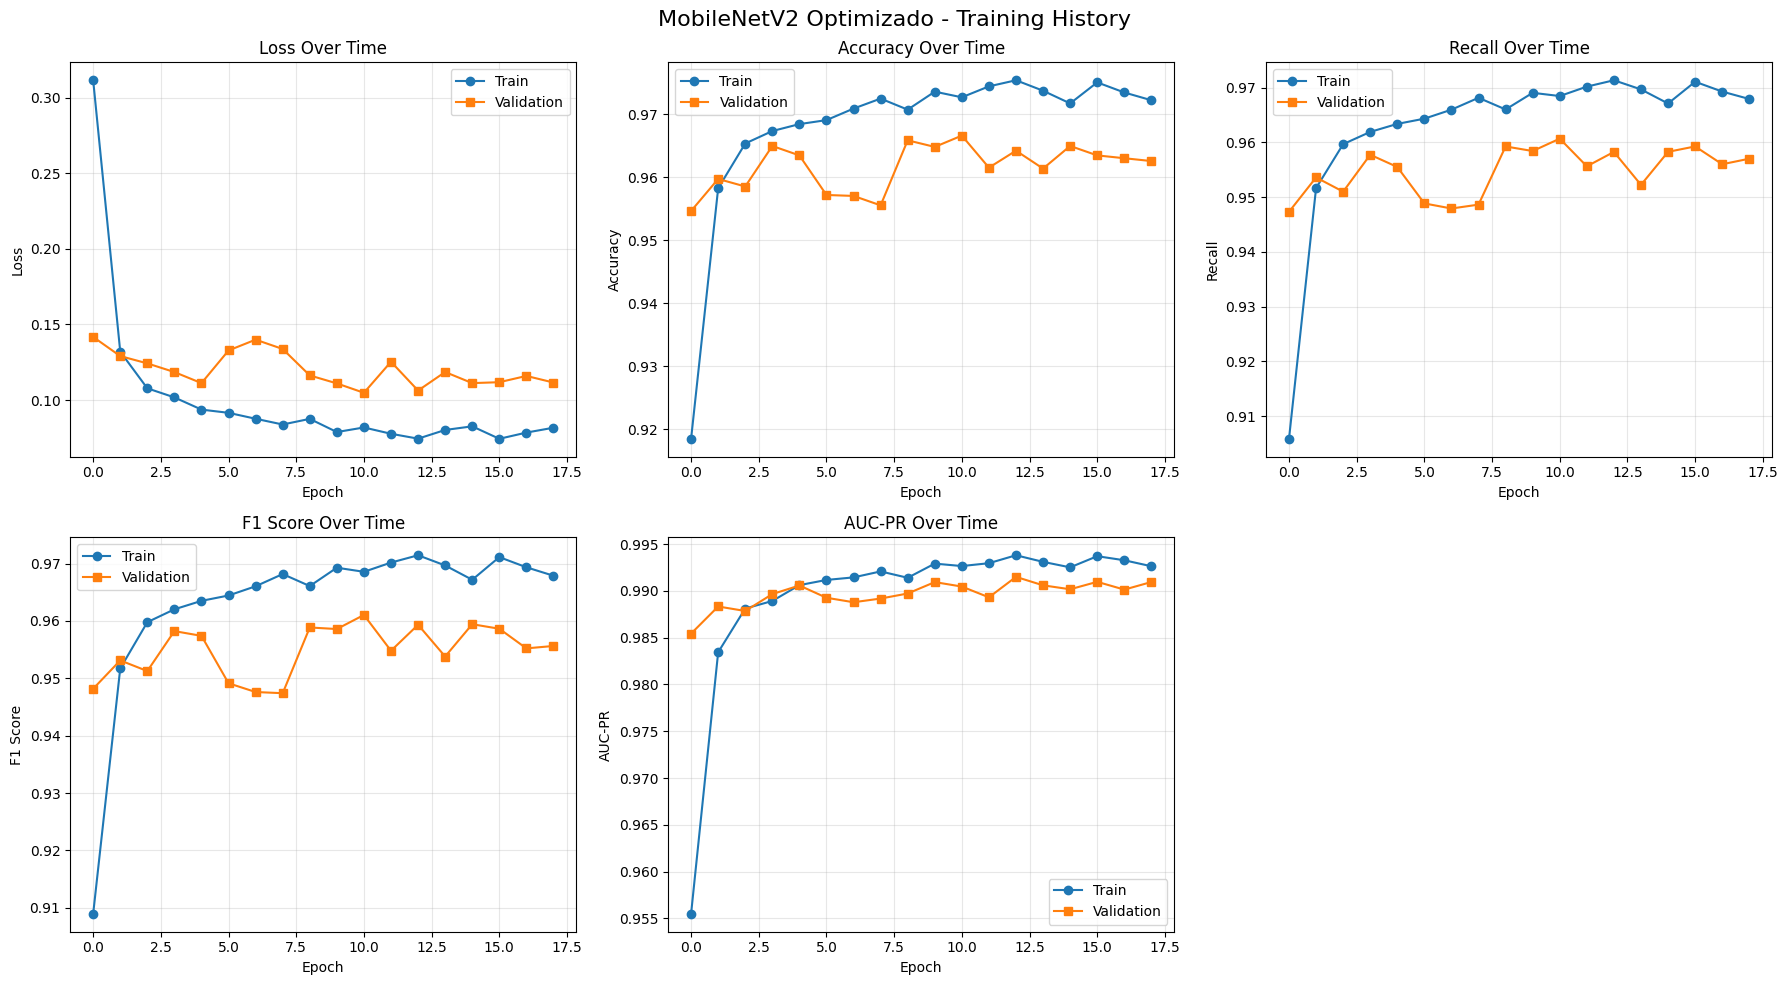

In [ ]:
print("="*70)
print("ENTRENANDO MODELO 1: MobileNetV2 Optimizado")
print("="*70)
print("📊 Técnicas de balanceo aplicadas:")
print("   1. WeightedRandomSampler en DataLoader de train")
print("   2. Class weights en CrossEntropyLoss")
print("="*70)

# Crear modelo con mejores hiperparámetros
model_v2_opt = create_model_with_custom_classifier(
    model=models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1),
    num_classes=num_classes,
    hidden_dim=best_params_v2['hidden_dim'],
    num_layers=best_params_v2['num_layers'],
    dropout=best_params_v2['dropout']
)

# Configurar optimizer y criterion
# TÉCNICA DE BALANCEO 2: Pesos por clase en la función de costo
# Los class_weights fueron calculados anteriormente y penalizan las clases más pobladas
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

if best_params_v2['optimizer'] == 'SGD':
    optimizer_v2 = optim.SGD(
        model_v2_opt.classifier.parameters(),
        lr=best_params_v2['lr'],
        momentum=0.9,
        weight_decay=best_params_v2['weight_decay']
    )
else:
    optimizer_v2 = optim.Adam(
        model_v2_opt.classifier.parameters(),
        lr=best_params_v2['lr'],
        weight_decay=best_params_v2['weight_decay']
    )

# Entrenar
num_epochs = 30
model_v2_opt, hist_v2, time_v2 = train_model(
    model_v2_opt,
    dataloaders_v2,
    criterion,
    optimizer_v2,
    num_epochs=num_epochs,
    patience=5,
    device=device
)

# Visualizar resultados
plot_history(hist_v2, title="MobileNetV2 Optimizado - Training History")


### 8.2 Modelo 2: MobileNetV3 Small


In [ ]:
# TÉCNICA DE BALANCEO 1: WeightedRandomSampler
# Usamos WeightedRandomSampler en lugar de shuffle=True para balancear el muestreo
optimal_batch_size = best_params_v3['batch_size']

# Crear WeightedRandomSampler para el dataset de entrenamiento
weighted_sampler_v3 = create_weighted_sampler(train_dataset, num_classes)

dataloaders_v3 = {
    'train': DataLoader(train_dataset, batch_size=optimal_batch_size, 
                    sampler=weighted_sampler_v3,  # Usar sampler en lugar de shuffle
                    num_workers=5, prefetch_factor=2, pin_memory=True,
                    persistent_workers=True, pin_memory_device="cuda"),
    'val': DataLoader(val_dataset, batch_size=optimal_batch_size, shuffle=False,
                     num_workers=5, prefetch_factor=2, pin_memory=True,
                  persistent_workers=True, pin_memory_device="cuda"),
    'test': DataLoader(test_dataset, batch_size=optimal_batch_size, shuffle=False,
                  num_workers=5, prefetch_factor=2, pin_memory=True,
                  persistent_workers=True, pin_memory_device="cuda")
}

print(f"✅ Dataloaders creados con batch_size={optimal_batch_size}")
print(f"   Train: {len(dataloaders_v3['train'])} batches (con WeightedRandomSampler)")
print(f"   Val: {len(dataloaders_v3['val'])} batches")
print(f"   Test: {len(dataloaders_v3['test'])} batches")

✅ Dataloaders creados con batch_size=32
   Train: 1675 imágenes (100% del dataset)
   Val: 209 imágenes (100% del dataset)
   Test: 211 imágenes (100% del dataset)



ENTRENANDO MODELO 2: MobileNetV3 Small
Epoch 1/30
----------
train Loss: 0.3801 Acc: 0.8904 Recall: 0.8733 F1: 0.8756 AUC-PR: 0.9303
val Loss: 0.2177 Acc: 0.9315 Recall: 0.9173 F1: 0.9174 AUC-PR: 0.9786
Epoch 2/30
----------
train Loss: 0.2060 Acc: 0.9353 Recall: 0.9252 F1: 0.9254 AUC-PR: 0.9680
val Loss: 0.1495 Acc: 0.9542 Recall: 0.9467 F1: 0.9460 AUC-PR: 0.9845
Epoch 3/30
----------
train Loss: 0.1744 Acc: 0.9455 Recall: 0.9374 F1: 0.9375 AUC-PR: 0.9754
val Loss: 0.1382 Acc: 0.9583 Recall: 0.9526 F1: 0.9523 AUC-PR: 0.9856
Epoch 4/30
----------
train Loss: 0.1670 Acc: 0.9489 Recall: 0.9409 F1: 0.9411 AUC-PR: 0.9766
val Loss: 0.1268 Acc: 0.9633 Recall: 0.9574 F1: 0.9574 AUC-PR: 0.9879
Epoch 5/30
----------
train Loss: 0.1555 Acc: 0.9520 Recall: 0.9445 F1: 0.9447 AUC-PR: 0.9795
val Loss: 0.1468 Acc: 0.9550 Recall: 0.9472 F1: 0.9467 AUC-PR: 0.9864
Epoch 6/30
----------
train Loss: 0.1560 Acc: 0.9522 Recall: 0.9449 F1: 0.9450 AUC-PR: 0.9790
val Loss: 0.1232 Acc: 0.9633 Recall: 0.9562 F1

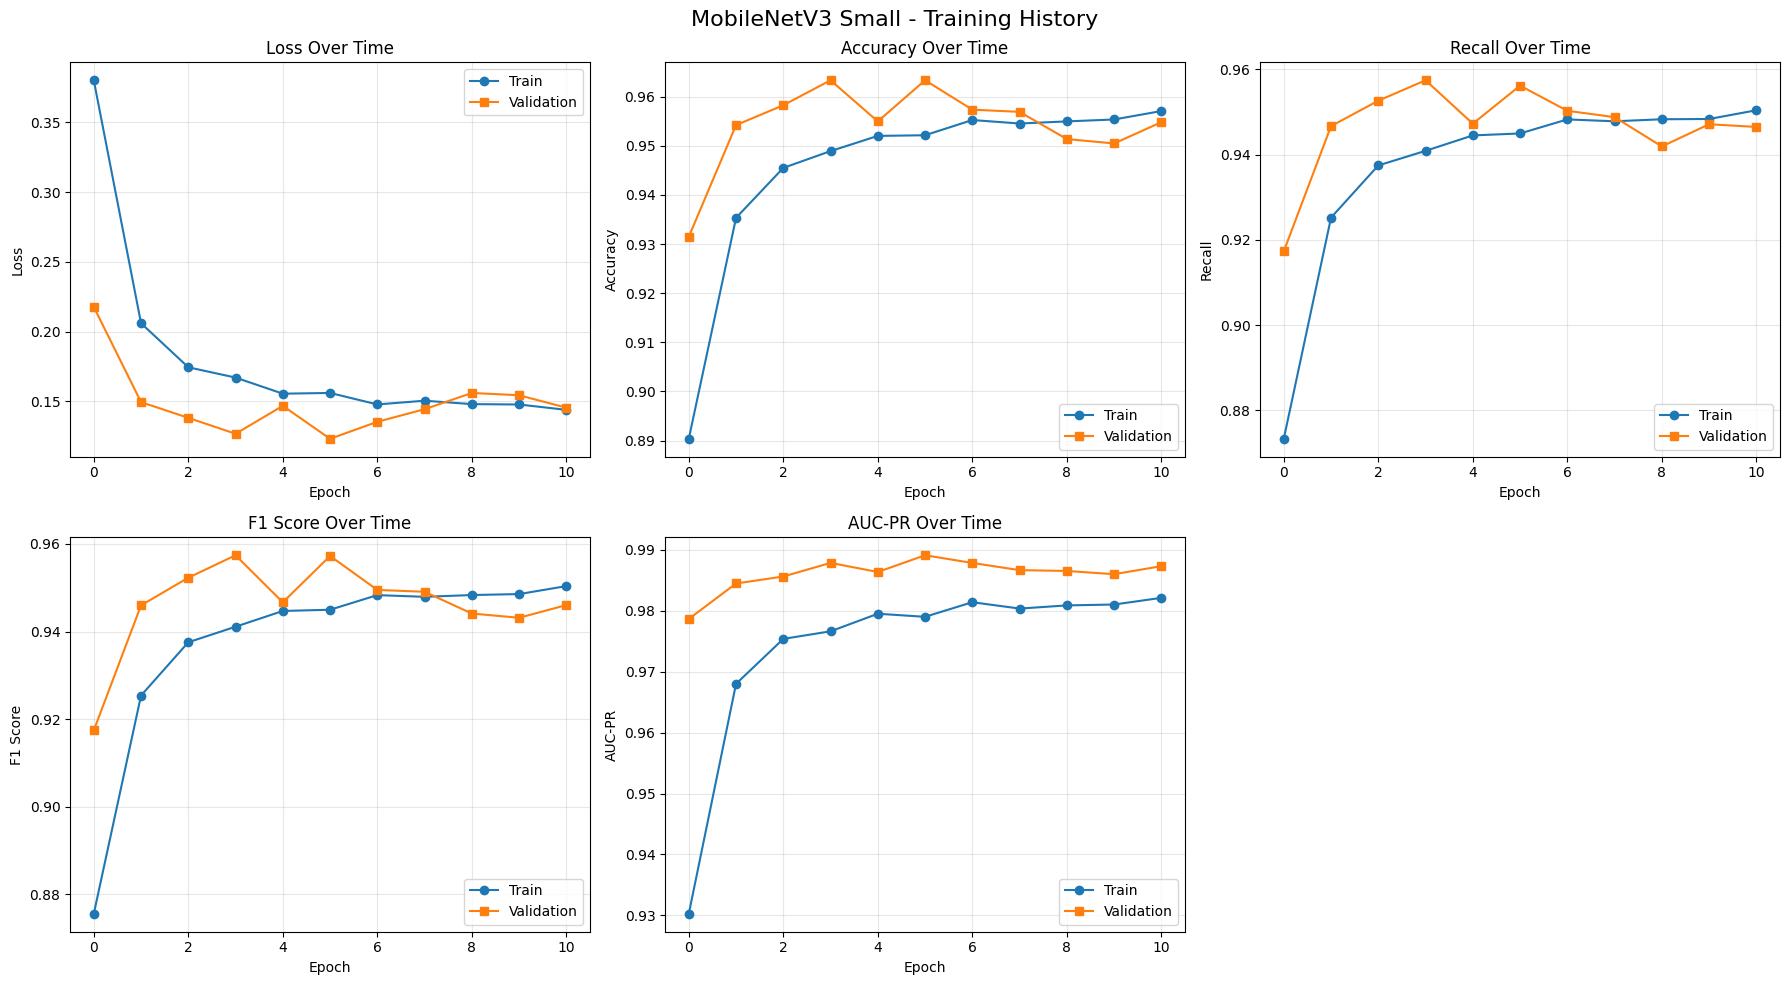

In [ ]:
print("\n" + "="*70)
print("ENTRENANDO MODELO 2: MobileNetV3 Small")
print("="*70)
print("📊 Técnicas de balanceo aplicadas:")
print("   1. WeightedRandomSampler en DataLoader de train")
print("   2. Class weights en CrossEntropyLoss")
print("="*70)

# Crear modelo con mejores hiperparámetros
model_v3_opt = create_model_with_custom_classifier(
    model=models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1),
    num_classes=num_classes,
    hidden_dim=best_params_v3['hidden_dim'],
    num_layers=best_params_v3['num_layers'],
    dropout=best_params_v3['dropout']
)

# Configurar optimizer y criterion
# TÉCNICA DE BALANCEO 2: Pesos por clase en la función de costo
# Los class_weights fueron calculados anteriormente y penalizan las clases más pobladas
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

if best_params_v3['optimizer'] == 'SGD':
    optimizer_v3 = optim.SGD(
        model_v3_opt.classifier.parameters(),
        lr=best_params_v3['lr'],
        momentum=0.9,
        weight_decay=best_params_v3['weight_decay']
    )
else:
    optimizer_v3 = optim.Adam(
        model_v3_opt.classifier.parameters(),
        lr=best_params_v2['lr'],
        weight_decay=best_params_v3['weight_decay']
    )

# Entrenar
num_epochs = 30
model_v3_opt, hist_v3, time_v3 = train_model(
    model_v3_opt,
    dataloaders_v3,
    criterion,
    optimizer_v3,
    num_epochs=num_epochs,
    patience=5,
    device=device
)

# Visualizar resultados
plot_history(hist_v3, title="MobileNetV3 Small - Training History")


## 9. Evaluación y Comparación de Modelos


In [30]:
print("="*70)
print("EVALUACIÓN DE MODELOS EN TEST SET")
print("="*70)

# Evaluar todos los modelos en CPU para comparación justa
print("\nEvaluando MobileNetV2...")
acc_v2, recall_v2, f1_v2, auc_pr_v2, inf_time_v2 = evaluate_model(model_v2_opt, dataloaders_v2['test'], 'cpu')
size_v2 = get_model_size(model_v2_opt, "v2_opt_temp")

print("\nEvaluando MobileNetV3...")
acc_v3, recall_v3, f1_v3, auc_pr_v3, inf_time_v3 = evaluate_model(model_v3_opt, dataloaders_v3['test'], 'cpu')
size_v3 = get_model_size(model_v3_opt, "v3_temp")

# Crear tabla de resultados
results = {
    'MobileNetV2': {
        'Accuracy': acc_v2,
        'Recall': recall_v2,
        'F1 Score': f1_v2,
        'AUC-PR': auc_pr_v2,
        'Size (MB)': size_v2,
        'Inference Time (s)': inf_time_v2
    },
    'MobileNetV3': {
        'Accuracy': acc_v3,
        'Recall': recall_v3,
        'F1 Score': f1_v3,
        'AUC-PR': auc_pr_v3,
        'Size (MB)': size_v3,
        'Inference Time (s)': inf_time_v3
    }
}

df_results = pd.DataFrame(results).T

print("\n" + "="*70)
print("RESUMEN DE RESULTADOS")
print("="*70)
print(df_results.to_string())
print("="*70)


EVALUACIÓN DE MODELOS EN TEST SET

Evaluando MobileNetV2...

Evaluando MobileNetV3...

RESUMEN DE RESULTADOS
             Accuracy    Recall  F1 Score    AUC-PR  Size (MB)  Inference Time (s)
MobileNetV2  0.966260  0.959609  0.960979  0.989836   9.331723          116.018183
MobileNetV3  0.956897  0.947741  0.949882  0.984985   3.924955           14.683842


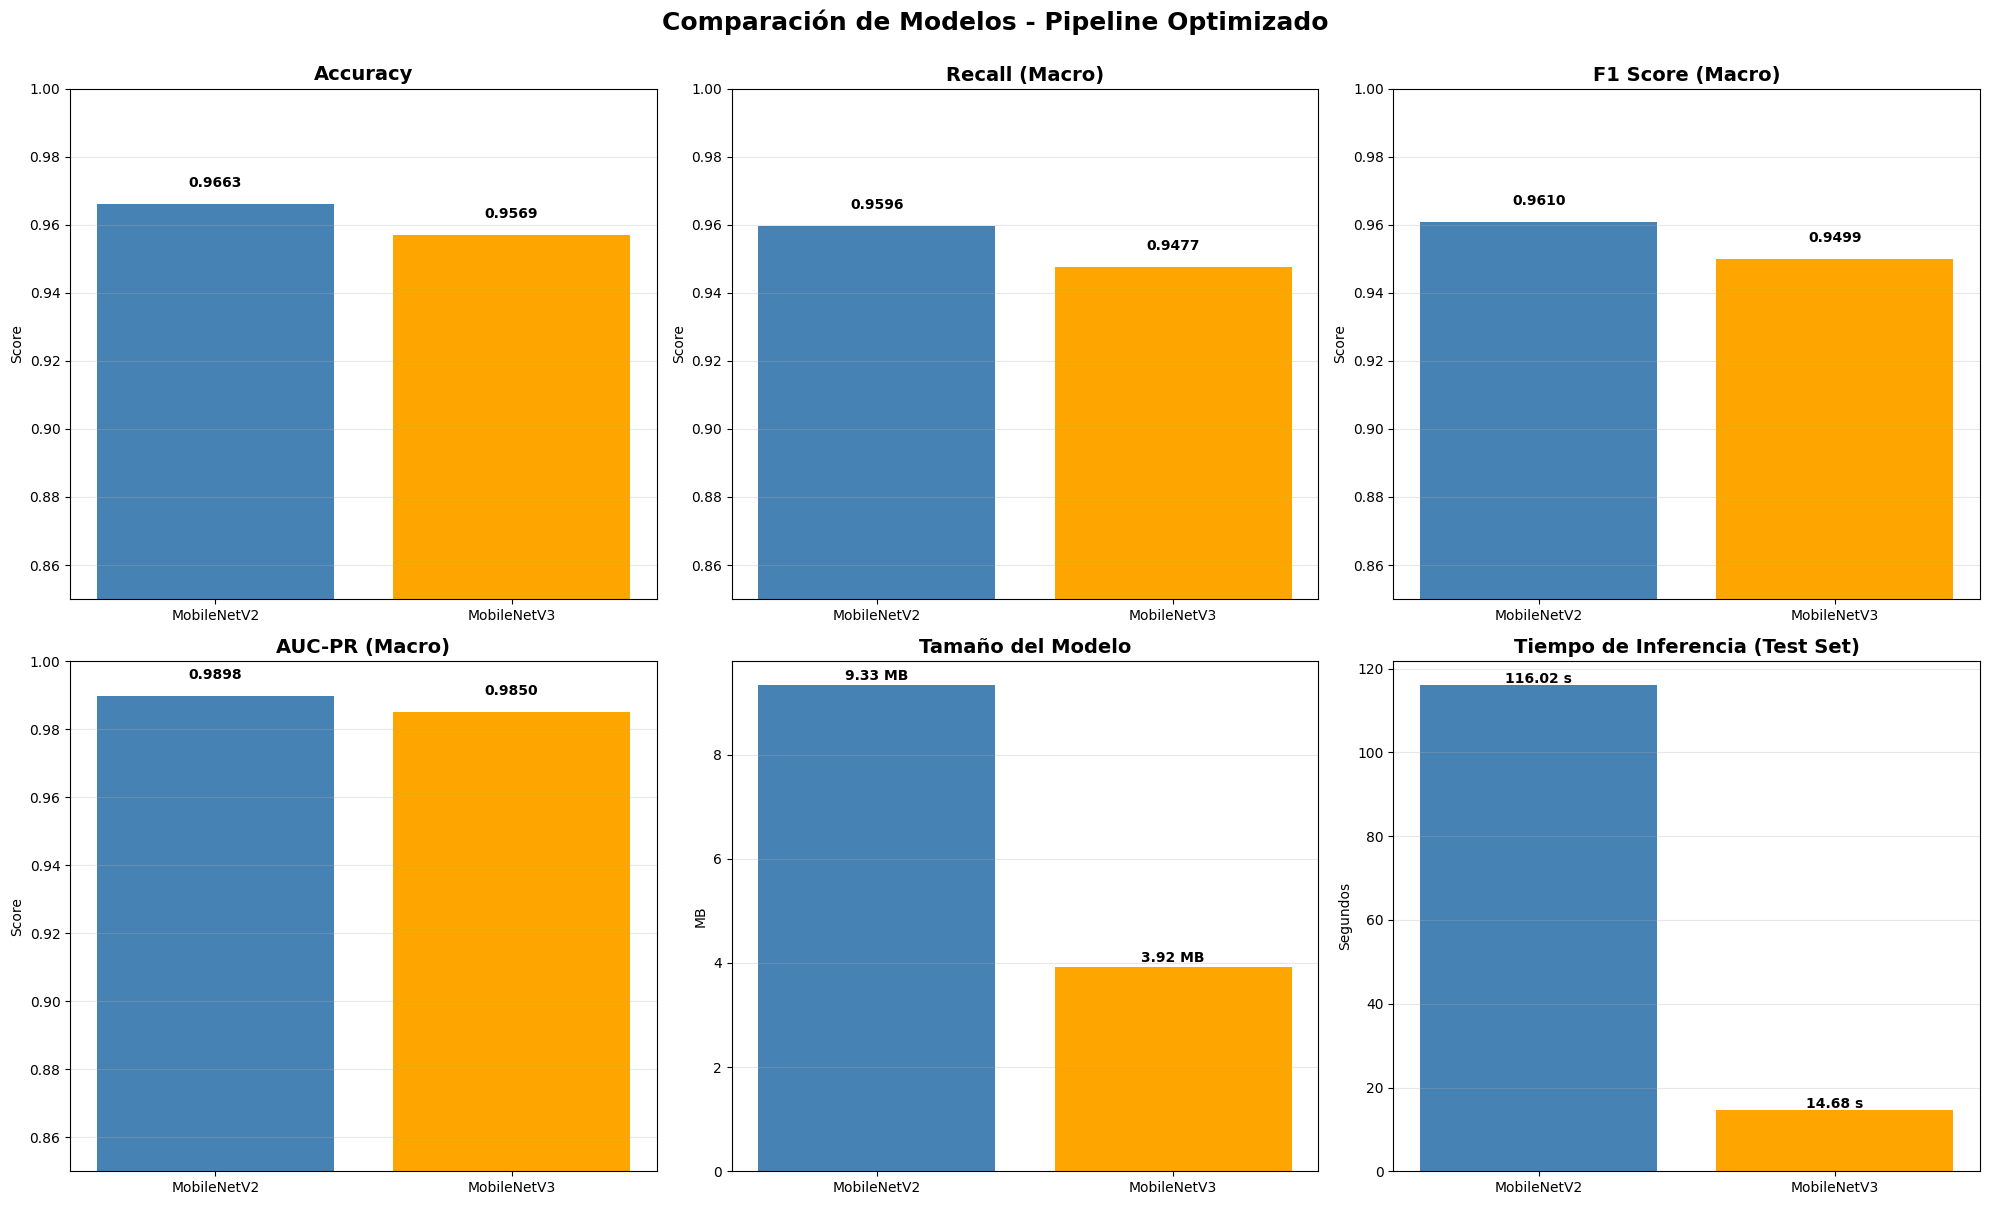

In [31]:
# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

models_list = df_results.index.tolist()
colors = ['steelblue', 'orange', 'forestgreen']

# 1. Accuracy
axes[0, 0].bar(models_list, df_results['Accuracy'], color=colors)
axes[0, 0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_ylim(0.85, 1.0)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Accuracy']):
    axes[0, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 2. Recall
axes[0, 1].bar(models_list, df_results['Recall'], color=colors)
axes[0, 1].set_title('Recall (Macro)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim(0.85, 1.0)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Recall']):
    axes[0, 1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 3. F1 Score
axes[0, 2].bar(models_list, df_results['F1 Score'], color=colors)
axes[0, 2].set_title('F1 Score (Macro)', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('Score')
axes[0, 2].set_ylim(0.85, 1.0)
axes[0, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['F1 Score']):
    axes[0, 2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 4. AUC-PR
axes[1, 0].bar(models_list, df_results['AUC-PR'], color=colors)
axes[1, 0].set_title('AUC-PR (Macro)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_ylim(0.85, 1.0)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['AUC-PR']):
    axes[1, 0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# 5. Tamaño del modelo
axes[1, 1].bar(models_list, df_results['Size (MB)'], color=colors)
axes[1, 1].set_title('Tamaño del Modelo', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('MB')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Size (MB)']):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f} MB', ha='center', fontweight='bold')

# 6. Tiempo de inferencia
axes[1, 2].bar(models_list, df_results['Inference Time (s)'], color=colors)
axes[1, 2].set_title('Tiempo de Inferencia (Test Set)', fontsize=14, fontweight='bold')
axes[1, 2].set_ylabel('Segundos')
axes[1, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_results['Inference Time (s)']):
    axes[1, 2].text(i, v + 0.5, f'{v:.2f} s', ha='center', fontweight='bold')

plt.suptitle('Comparación de Modelos - Pipeline Optimizado',
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## 10. Resumen

Comparamos el impacto de nuestras optimizaciones:


In [ ]:
print("="*70)
print("RESUMEN")
print("="*70)

print("\n1️⃣ ELIMINACIÓN DE DUPLICADOS")
print(f"   • Imágenes duplicadas eliminadas: {removed if duplicates else 0}")
print(f"   • Beneficio: Reduce overfitting y mejora generalización")

print("\n2️⃣ DATA AUGMENTATION SELECTIVO")
print(f"   • Imágenes sintéticas generadas: {generated_images}")
print(f"   • Clases balanceadas: {len(underrepresented_classes)}")
print(f"   • Beneficio: Mejora rendimiento en clases minoritarias")

print("\n3️⃣ TÉCNICAS DE BALANCEO DEL DATASET (Sugeridas por el profesor)")
print("   📌 WeightedRandomSampler:")
print("      • Muestrea aleatoriamente dando mayor probabilidad a clases minoritarias")
print("      • Uniforima la distribución durante el entrenamiento")
print("      • No modifica el dataset original, solo el muestreo")
print("   📌 Class Weights en CrossEntropyLoss:")
print("      • Penaliza errores en clases menos pobladas")
print(f"      • Rango de pesos: [{class_weights.min().item():.4f}, {class_weights.max().item():.4f}]")
print("   • Beneficio: Modelo más robusto en todas las clases")

print("\n4️⃣ OPTIMIZACIÓN DE HIPERPARÁMETROS (OPTUNA) V2")
print(f"   • Trials ejecutados: {10}")
print(f"   • Mejor AUC PR Score encontrado: {0.98564:.4f}")
print("   • Hiperparámetros optimizados:")
for key, value in best_params_v2.items():
    print(f"     - {key}: {value}")

print("\n   OPTIMIZACIÓN DE HIPERPARÁMETROS (OPTUNA) V3")
print(f"   • Trials ejecutados: {10}")
print(f"   • Mejor AUC PR Score encontrado: {0.97122:.4f}")
print("   • Hiperparámetros optimizados:")
for key, value in best_params_v3.items():
    print(f"     - {key}: {value}")
print(f"   • Beneficio: Configuración óptima automática")

print("\n" + "="*70)


RESUMEN

1️⃣ ELIMINACIÓN DE DUPLICADOS
   • Imágenes duplicadas eliminadas: 21
   • Beneficio: Reduce overfitting y mejora generalización

2️⃣ DATA AUGMENTATION SELECTIVO
   • Imágenes sintéticas generadas: 4078
   • Clases balanceadas: 23
   • Beneficio: Mejora rendimiento en clases minoritarias

3️⃣ OPTIMIZACIÓN DE HIPERPARÁMETROS (OPTUNA) V2
   • Trials ejecutados: 10
   • Mejor AUC PR Score encontrado: 0.9856
   • Hiperparámetros optimizados:
     - lr: 0.0021413341205744167
     - batch_size: 64
     - hidden_dim: 512
     - num_layers: 1
     - dropout: 0.22613400786478782
     - optimizer: Adam
     - weight_decay: 0.00024393465462152218

OPTIMIZACIÓN DE HIPERPARÁMETROS (OPTUNA) V3
   • Trials ejecutados: 10
   • Mejor AUC PR Score encontrado: 0.9712
   • Hiperparámetros optimizados:
     - lr: 0.059329444680960054
     - batch_size: 32
     - hidden_dim: 512
     - num_layers: 1
     - dropout: 0.4225091797371915
     - optimizer: SGD
     - weight_decay: 0.0001771479661600252


## 11. Guardar Modelos y Configuración

Guardamos los modelos entrenados y la configuración para uso posterior.


In [33]:
# Guardar modelos
torch.save(model_v2_opt.state_dict(), 'mobilenetv2_optimized.pth')
torch.save(model_v3_opt.state_dict(), 'mobilenetv3_small.pth')

# Guardar hiperparámetros óptimos
import json

config = {
    'best_hyperparameters_v2': best_params_v2,
    'best_hyperparameters_v3': best_params_v3,
    'num_classes': num_classes,
    'class_names': full_dataset.classes,
    'results': results
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2, default=str)

print("✅ Modelos y configuración guardados:")
print("   - mobilenetv2_optimized.pth")
print("   - mobilenetv3_small.pth")
print("   - model_config.json")

# Guardar resultados en CSV
df_results.to_csv('model_comparison_results.csv')
print("   - model_comparison_results.csv")


✅ Modelos y configuración guardados:
   - mobilenetv2_optimized.pth
   - mobilenetv3_small.pth
   - model_config.json
   - model_comparison_results.csv
